In [65]:
 ########  A.1  ######## 

# on recup les taux depuis l'URL

import urllib.request
from pathlib import Path

import json

import pandas as pd



URL = "https://api.frankfurter.dev/v1/2026-01-01..2026-09-01?from=EUR&to=USD"

CHEMIN_CSV = Path("donnees/taux.csv")



def recuperer_taux(url):

    requete = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})

    with urllib.request.urlopen(requete) as reponse : 
        data = json.load(reponse)

    df = pd.DataFrame.from_dict(data["rates"], orient="index")

    df.index = pd.to_datetime(df.index)

    df.index.name = "date"
    return df.sort_index()



df = recuperer_taux(URL)

df.head()

,USD
date,
2025-12-31,1.1750
2026-01-02,1.1721
2026-01-05,1.1664
2026-01-06,1.1707
2026-01-07,1.1684


In [66]:
df.describe

<bound method NDFrame.describe of                USD
date              
2025-12-31  1.1750
2026-01-02  1.1721
2026-01-05  1.1664
2026-01-06  1.1707
2026-01-07  1.1684
...            ...
2026-08-26  1.1669
2026-08-27  1.1645
2026-08-28  1.1643
2026-08-31  1.1596
2026-09-01  1.1590

[171 rows x 1 columns]>

In [67]:
df.dtypes

USD    float64
dtype: object

In [68]:
 ########  A.2  ######## 


#df.loc[df.USD > 1.17].count()


#df.loc[df.index > "2026-08-12"]


print("moyenne = ", df.USD.mean())
print("minimum = ", df.USD.min())
print("maximum = ", df.USD.max())








moyenne =  1.1623684210526317
minimum =  1.134
maximum =  1.1974


In [69]:


 ########  B.1 ######## 


dates_ouvrees = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="B"
)

df = df.reindex(dates_ouvrees)

df = df.ffill()

df.head()


,USD
2025-12-31,1.1750
2026-01-01,1.1750
2026-01-02,1.1721
2026-01-05,1.1664
2026-01-06,1.1707


In [70]:


 ########  B.2 ######## 


#Variation en % sur toute la période
variation = (df["USD"].iloc[-1] / df["USD"].iloc[0] - 1) * 100
variation = round(variation, 3)
print("Variation sur la période :", variation, "%")


df["moyenne_mobile"] = df["USD"].rolling(window = 5).mean()

df







Variation sur la période : -1.362 %


,USD,moyenne_mobile
2025-12-31,1.1750,NaN
2026-01-01,1.1750,NaN
2026-01-02,1.1721,NaN
2026-01-05,1.1664,NaN
2026-01-06,1.1707,1.17184
...,...,...
2026-08-26,1.1669,1.16750
2026-08-27,1.1645,1.16678
2026-08-28,1.1643,1.16566
2026-08-31,1.1596,1.16430


In [71]:
new_df = df["USD"].resample("ME").mean()

new_df.head()

2025-12-31    1.175000
2026-01-31    1.173877
2026-02-28    1.182395
2026-03-31    1.155832
2026-04-30    1.168991
Freq: ME, Name: USD, dtype: float64

In [74]:
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#

########  C   ########


# Je récupère les taux Euro/Yen

URL_JPY = "https://api.frankfurter.dev/v1/2026-01-01..2026-09-01?from=EUR&to=JPY"

df2 = recuperer_taux(URL_JPY)

df2 = df2.reindex(dates_ouvrees)

df2 = df2.ffill()

df2.head()





,JPY
2025-12-31,184.09
2026-01-01,184.09
2026-01-02,183.94
2026-01-05,182.93
2026-01-06,183.14


In [75]:
# Je récupère les taux Euro/Livres Sterling

URL_GBP = "https://api.frankfurter.dev/v1/2026-01-01..2026-09-01?from=EUR&to=GBP"

df3 = recuperer_taux(URL_GBP)

df3 = df3.reindex(dates_ouvrees)

df3 = df3.ffill()

df3.head()

,GBP
2025-12-31,0.8726
2026-01-01,0.8726
2026-01-02,0.8719
2026-01-05,0.8676
2026-01-06,0.8663


In [77]:
#taux = pd.concat([df,df2,df3], axis=1)
taux = pd.merge(df, df2, left_index=True, right_index=True)
taux = pd.merge(taux, df3, left_index=True, right_index=True)
taux

,USD,moyenne_mobile,JPY,GBP
2025-12-31,1.1750,NaN,184.09,0.87260
2026-01-01,1.1750,NaN,184.09,0.87260
2026-01-02,1.1721,NaN,183.94,0.87190
2026-01-05,1.1664,NaN,182.93,0.86760
2026-01-06,1.1707,1.17184,183.14,0.86630
...,...,...,...,...
2026-08-26,1.1669,1.16750,185.62,0.85613
2026-08-27,1.1645,1.16678,185.61,0.85740
2026-08-28,1.1643,1.16566,185.92,0.85720
2026-08-31,1.1596,1.16430,185.22,0.85648


In [80]:
taux.drop("moyenne_mobile", axis=1)

,USD,JPY,GBP
2025-12-31,1.1750,184.09,0.87260
2026-01-01,1.1750,184.09,0.87260
2026-01-02,1.1721,183.94,0.87190
2026-01-05,1.1664,182.93,0.86760
2026-01-06,1.1707,183.14,0.86630
...,...,...,...
2026-08-26,1.1669,185.62,0.85613
2026-08-27,1.1645,185.61,0.85740
2026-08-28,1.1643,185.92,0.85720
2026-08-31,1.1596,185.22,0.85648


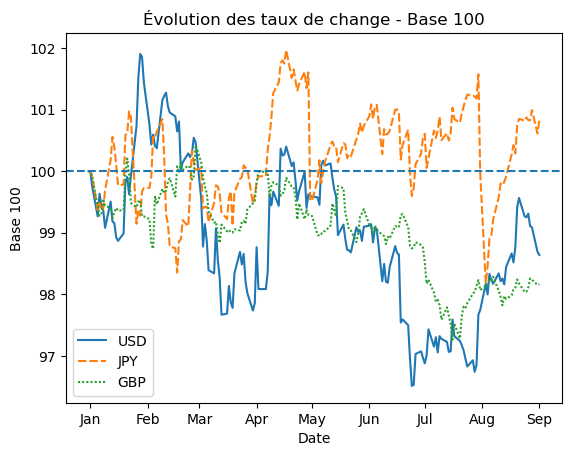

In [82]:
# Bonus


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

taux_base100 = taux[["USD", "JPY", "GBP"]] / taux[["USD", "JPY", "GBP"]].iloc[0] * 100

sns.lineplot(data=taux_base100)

plt.axhline(100, linestyle="--")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.xlabel("Date")
plt.ylabel("Base 100")
plt.title("Évolution des taux de change - Base 100")

plt.show()


In [90]:
########  D.1   ########

import numpy as np

usd_np = df["USD"].to_numpy()

moyenne = usd_np.mean()
ecart_type = usd_np.std(ddof=1)

variations = usd_np[1:] / usd_np[:-1] - 1

print("Moyenne :", moyenne)
print("Écart-type :", ecart_type)
print("Variations :", variations)


Moyenne : 1.1623725714285715
Écart-type : 0.014248760450798398
Variations : [ 0.00000000e+00 -2.46808511e-03 -4.86306629e-03  3.68655693e-03
 -1.96463654e-03 -7.70284149e-04 -2.82655246e-03  4.29479471e-03
 -3.25008553e-03 -2.57422344e-04 -2.31739765e-03 -6.02202340e-04
  1.20513041e-03  8.33978162e-03  9.37926330e-04 -2.81114235e-03
  3.07534598e-03  8.00545052e-03  7.85738425e-03  3.77231956e-03
 -5.01085686e-04 -4.09425134e-03 -6.62807282e-03 -3.29391892e-03
  1.61003305e-03 -1.86125212e-03 -3.39040515e-04  7.80057656e-03
  6.73060744e-04  5.04456028e-04 -2.18487395e-03 -1.01061142e-03
 -5.90119710e-04 -2.44622522e-03  1.60662946e-03 -7.76699029e-03
  1.19118523e-03  1.44471828e-03 -5.94025798e-04  5.94378874e-04
  2.54582485e-03 -7.61808024e-04 -9.06395595e-03 -7.86459224e-03
  3.70498018e-03 -2.66117263e-03 -4.90618007e-03 -5.18986247e-04
  7.44266551e-03 -5.15419637e-03 -2.93584319e-03 -6.14878323e-03
  1.74276751e-04  4.61752919e-03 -2.68840517e-03 -9.56521739e-04
  5.74462529e-

In [91]:
########  D.2   ########
# Type des éléments du tableau NumPy
print(usd_np.dtype)

# Broadcasting : on multiplie tout le tableau par 100
usd_x100 = usd_np * 100

print(usd_x100[:5])


float64
[117.5  117.5  117.21 116.64 117.07]


In [94]:
######## D.3 ########

%pip install polars

Note: you may need to restart the kernel to use updated packages.


In [95]:
import polars as pl
import time

# Recréer le DataFrame pandas avec les 3 devises
taux_df = df.join([df2, df3])

# Convertir pandas -> polars
taux_polars = pl.from_pandas(taux_df.reset_index())

# Moyenne du taux USD
moyenne_polars = taux_polars.select(
    pl.col("USD").mean()
)

print(moyenne_polars)

# Variation jour à jour du taux USD
taux_polars = taux_polars.with_columns(
    pl.col("USD").pct_change().alias("variation_USD")
)

print(taux_polars.head())

shape: (1, 1)
┌──────────┐
│ USD      │
│ ---      │
│ f64      │
╞══════════╡
│ 1.162373 │
└──────────┘
shape: (5, 6)
┌─────────────────────┬────────┬────────────────┬────────┬────────┬───────────────┐
│ index               ┆ USD    ┆ moyenne_mobile ┆ JPY    ┆ GBP    ┆ variation_USD │
│ ---                 ┆ ---    ┆ ---            ┆ ---    ┆ ---    ┆ ---           │
│ datetime[ns]        ┆ f64    ┆ f64            ┆ f64    ┆ f64    ┆ f64           │
╞═════════════════════╪════════╪════════════════╪════════╪════════╪═══════════════╡
│ 2025-12-31 00:00:00 ┆ 1.175  ┆ null           ┆ 184.09 ┆ 0.8726 ┆ null          │
│ 2026-01-01 00:00:00 ┆ 1.175  ┆ null           ┆ 184.09 ┆ 0.8726 ┆ 0.0           │
│ 2026-01-02 00:00:00 ┆ 1.1721 ┆ null           ┆ 183.94 ┆ 0.8719 ┆ -0.002468     │
│ 2026-01-05 00:00:00 ┆ 1.1664 ┆ null           ┆ 182.93 ┆ 0.8676 ┆ -0.004863     │
│ 2026-01-06 00:00:00 ┆ 1.1707 ┆ 1.17184        ┆ 183.14 ┆ 0.8663 ┆ 0.003687      │
└─────────────────────┴────────┴─────────